# <span style="color:brown"><center>LOAN ELIGIBILITY PREDICTION

### <span style="color:blue"> IMPORTING PYTHON LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score, classification_report, roc_curve
import scipy.stats as stats
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

In [2]:
loan_data = pd.read_csv("Loan_Data.csv")

In [3]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
loan_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
data = loan_data.drop(columns = ['Loan_ID'], inplace = False)

In [6]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [7]:
loan_data.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [8]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.412162,85.587325,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.000000,65.120410,12.0,360.0,360.0,360.00,480.0
Credit_History,564.0,0.842199,0.364878,0.0,1.0,1.0,1.00,1.0


### <span style="color:blue"> EXPLORATORY DATA ANALYSIS (EDA)

#### <span style="color:green"> NUMERICAL VARIABLES UNIVARIATE ANALYSIS

<AxesSubplot:xlabel='ApplicantIncome'>

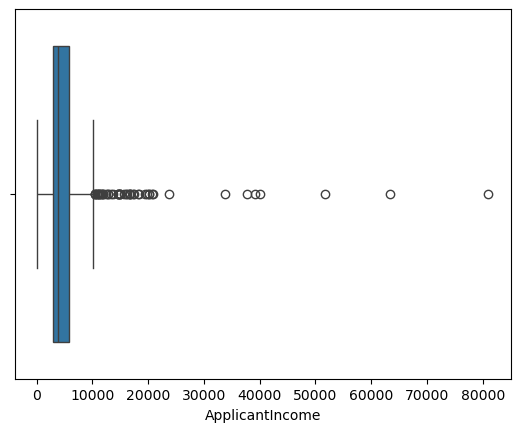

In [9]:
sns.boxplot(x=data['ApplicantIncome'])

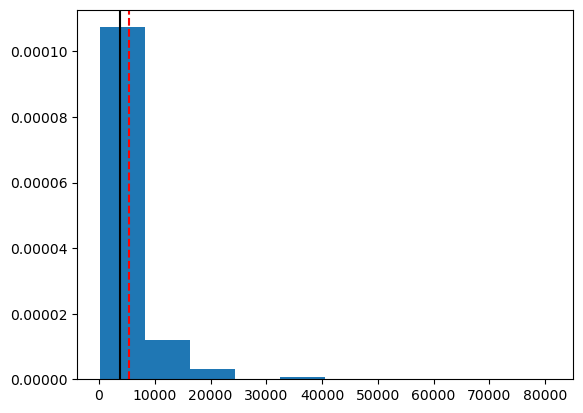

In [10]:
hist = plt.hist(x=data['ApplicantIncome'], density = True)
plt.axvline(data['ApplicantIncome'].mean(), color = 'red', linestyle='--')
plt.axvline(data['ApplicantIncome'].median(), color = 'black', linestyle='-')

<span style="color:blue"> Applicant income has mean and median close to each other.
The distributuion of applicant income is positively skewed with outliers at the right(aligned with expected value).

<AxesSubplot:xlabel='CoapplicantIncome'>

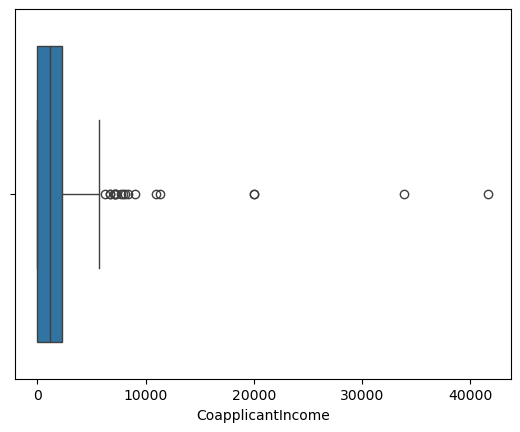

In [11]:
sns.boxplot(x=data['CoapplicantIncome'])

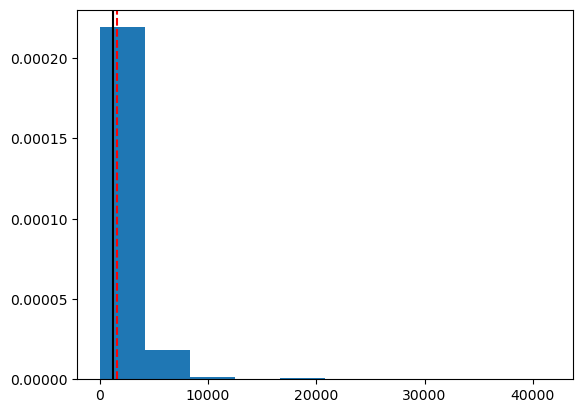

In [12]:
hist = plt.hist(x=data['CoapplicantIncome'], density = True)
plt.axvline(data['CoapplicantIncome'].mean(), color = 'red', linestyle='--')
plt.axvline(data['CoapplicantIncome'].median(), color = 'black', linestyle='-')

<span style="color:blue"> Positively skewed with outliers at the right(aligned with expected value). Mean and median are close enough.

<AxesSubplot:xlabel='LoanAmount'>

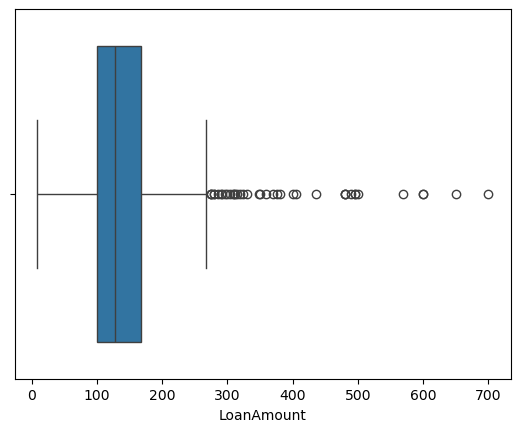

In [13]:
sns.boxplot(x=data['LoanAmount'])

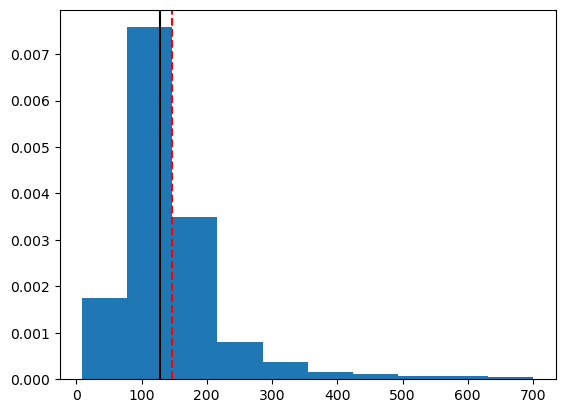

In [14]:
hist = plt.hist(x = data['LoanAmount'],density= True)
plt.axvline(x=data['LoanAmount'].mean(),color='red',linestyle='--')
plt.axvline(x=data['LoanAmount'].median(),color='black',linestyle='-')


<span style="color:blue">slightly positively skewed mean and median are close enough. Outliers are on the right side which need to be treated.

### <span style="color:blue">CATEGORICAL FEATURES - UNIVARIATE ANALYSIS

(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3+')])

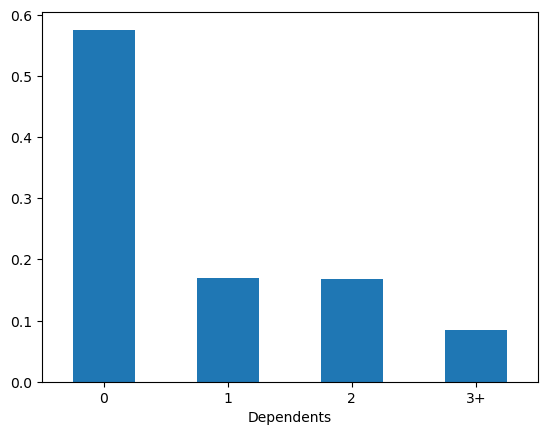

In [15]:
data['Dependents'].value_counts(normalize = True).plot.bar()
plt.xticks(rotation = 0)

(array([0, 1]), [Text(0, 0, 'Male'), Text(1, 0, 'Female')])

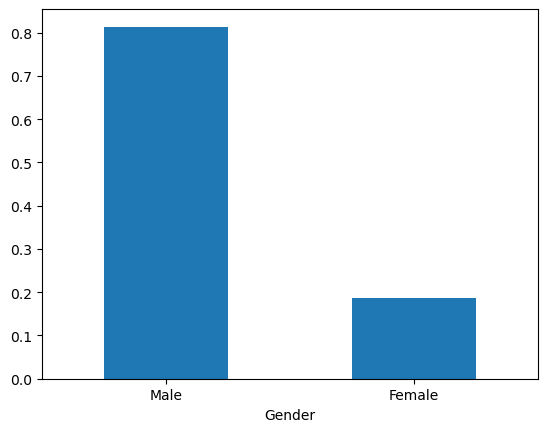

In [16]:
data['Gender'].value_counts(normalize = True).plot.bar()
plt.xticks(rotation = 0)

(array([0, 1]), [Text(0, 0, 'Yes'), Text(1, 0, 'No')])

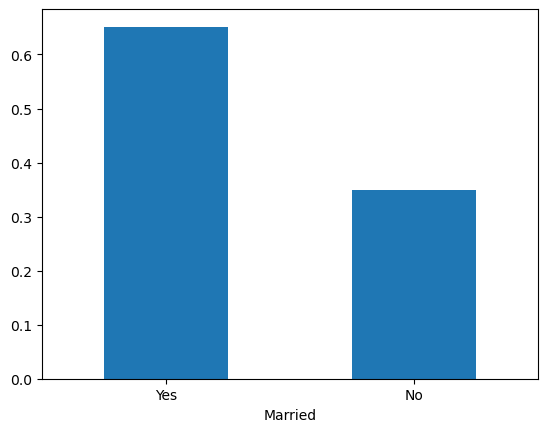

In [17]:
data['Married'].value_counts(normalize = True).plot.bar()
plt.xticks(rotation = 0)

(array([0, 1]), [Text(0, 0, 'No'), Text(1, 0, 'Yes')])

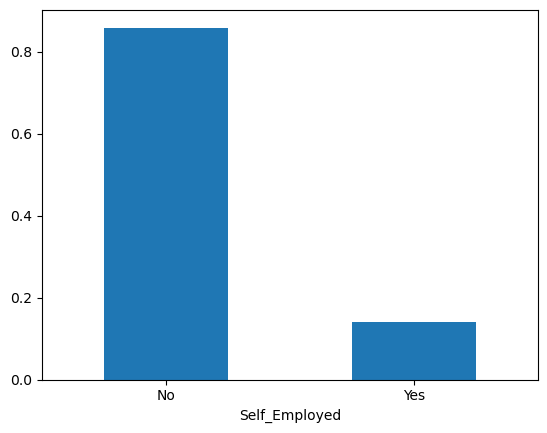

In [18]:
data['Self_Employed'].value_counts(normalize = True).plot.bar()
plt.xticks(rotation = 0)

(array([0, 1]), [Text(0, 0, '1.0'), Text(1, 0, '0.0')])

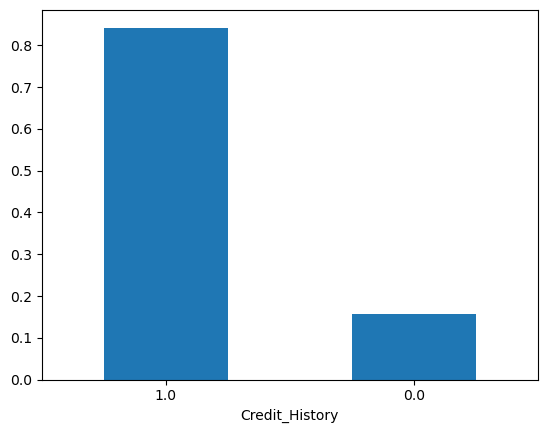

In [19]:
data['Credit_History'].value_counts(normalize = True).plot.bar()
plt.xticks(rotation = 0)

(array([0, 1, 2]),
 [Text(0, 0, 'Semiurban'), Text(1, 0, 'Urban'), Text(2, 0, 'Rural')])

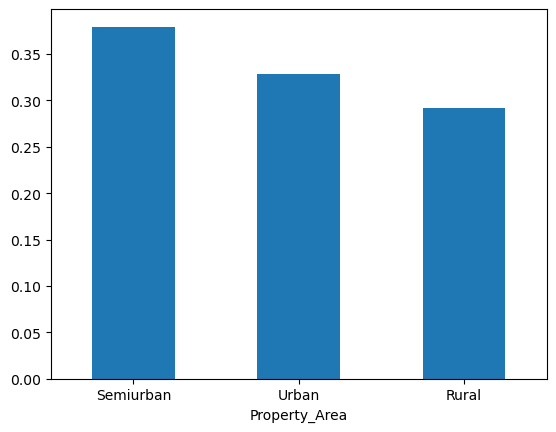

In [20]:
data['Property_Area'].value_counts(normalize= True).plot.bar()
plt.xticks(rotation=0)

(array([0, 1]), [Text(0, 0, 'Y'), Text(1, 0, 'N')])

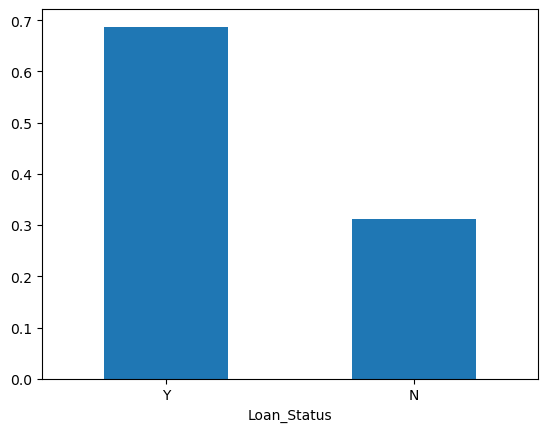

In [21]:
data['Loan_Status'].value_counts(normalize= True).plot.bar()
plt.xticks(rotation=0)

(array([0, 1]), [Text(0, 0, 'Graduate'), Text(1, 0, 'Not Graduate')])

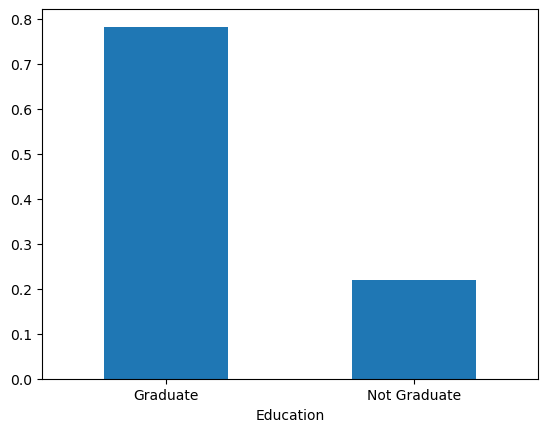

In [22]:
data['Education'].value_counts(normalize= True).plot.bar()
plt.xticks(rotation= 0)

### <span style="color:blue">BIVARIATE ANALYSIS

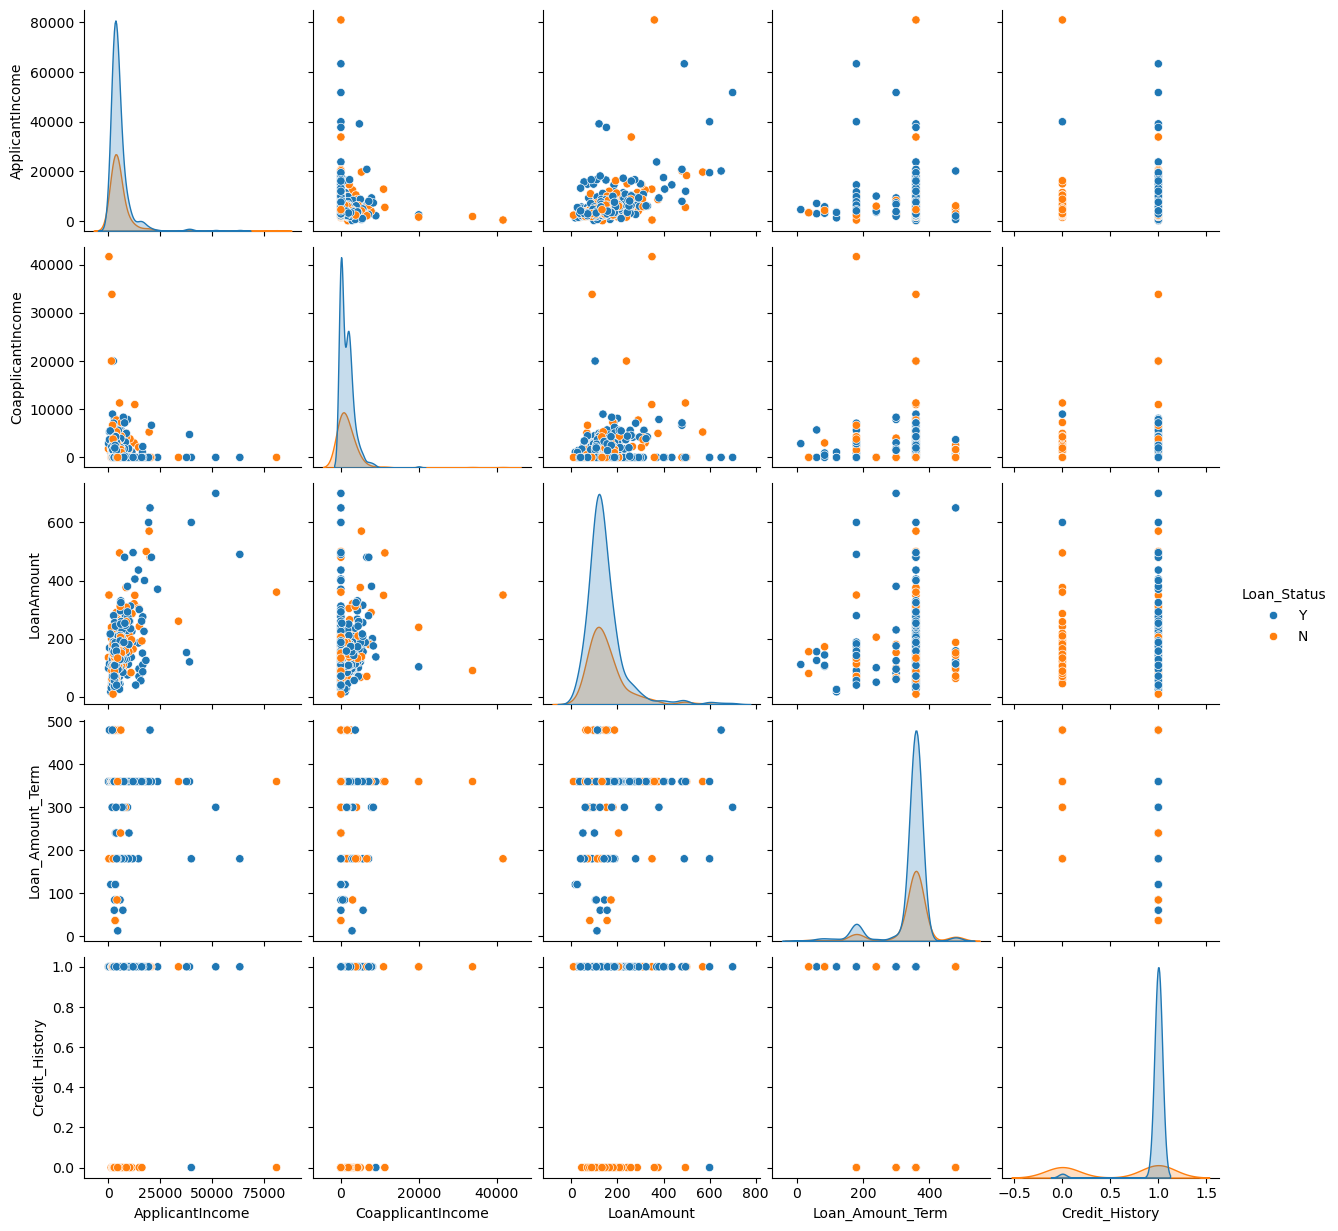

In [23]:
sns.pairplot(loan_data, diag_kind= 'kde', hue = 'Loan_Status')

In [26]:
numeric_data = data.select_dtypes(include=['number'])

numeric_data.corr()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000


In [27]:
numeric_data.corr(method='spearman')

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.320056,0.515397,-0.040111,0.043241
CoapplicantIncome,-0.320056,1.000000,0.240719,-0.013747,-0.007458
LoanAmount,0.515397,0.240719,1.000000,0.041486,-0.002361
Loan_Amount_Term,-0.040111,-0.013747,0.041486,1.000000,0.015088
Credit_History,0.043241,-0.007458,-0.002361,0.015088,1.000000


<AxesSubplot:>

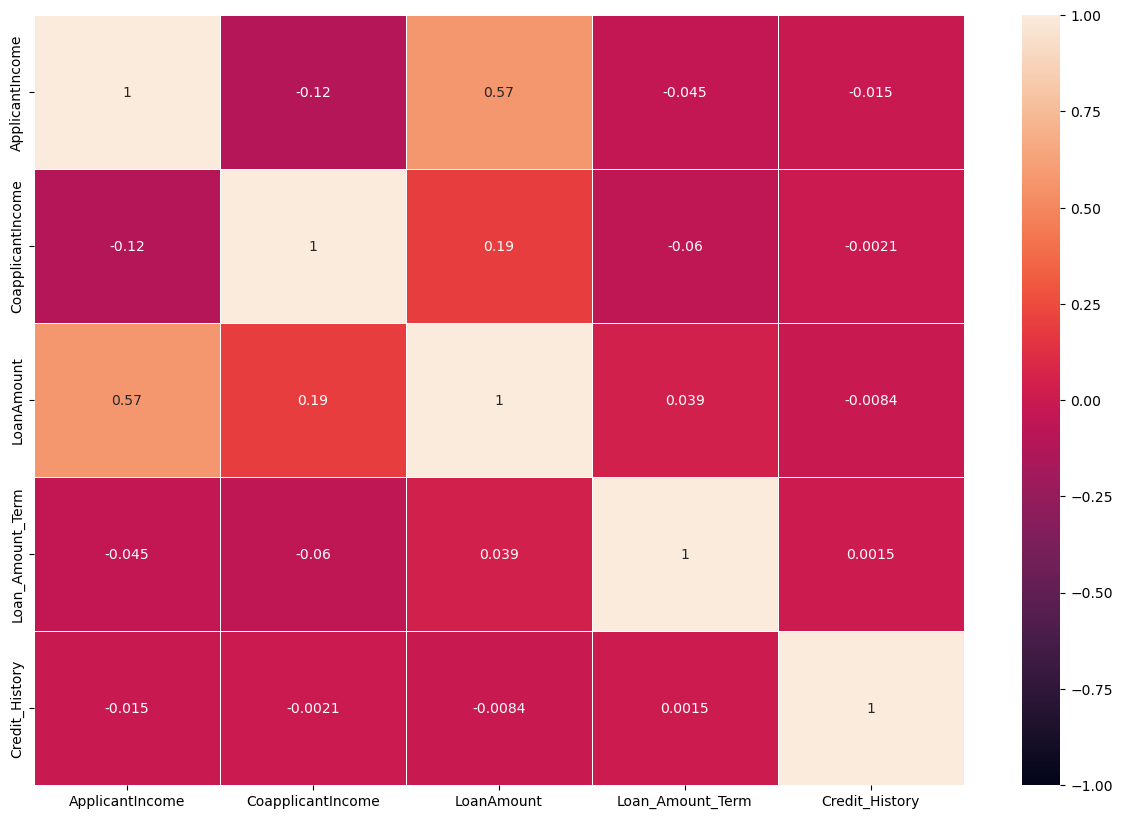

In [29]:
plt.figure(figsize=(15,10))
sns.heatmap(numeric_data.corr(),annot= True,linewidths=.5, vmin = -1, vmax = 1, fmt = '.2g')

<AxesSubplot:>

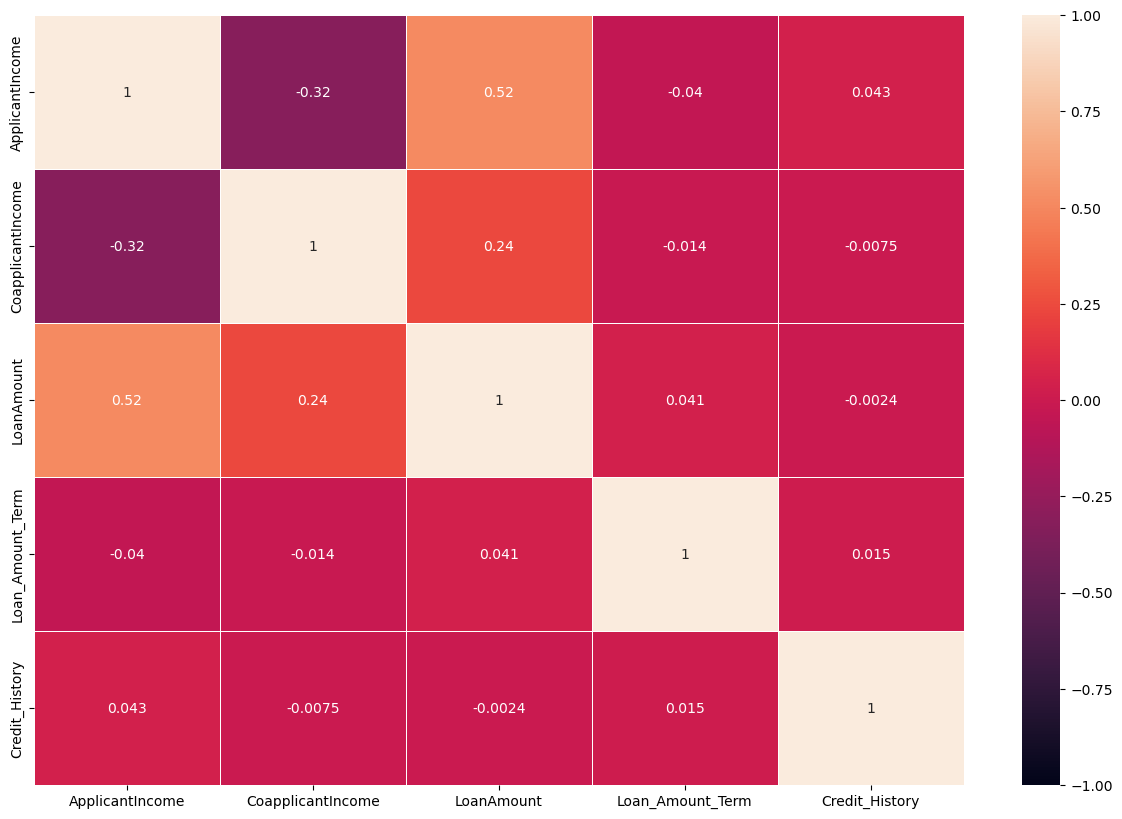

In [30]:
plt.figure(figsize=(15,10))
sns.heatmap(numeric_data.corr(method='spearman'),annot= True,linewidths=.5, vmin = -1, vmax = 1, fmt = '.2g')

<span style="color:blue">There is high positive correlation between loan amount and applicant income so to avoid multicollinearity we drop any of the two

<AxesSubplot:>

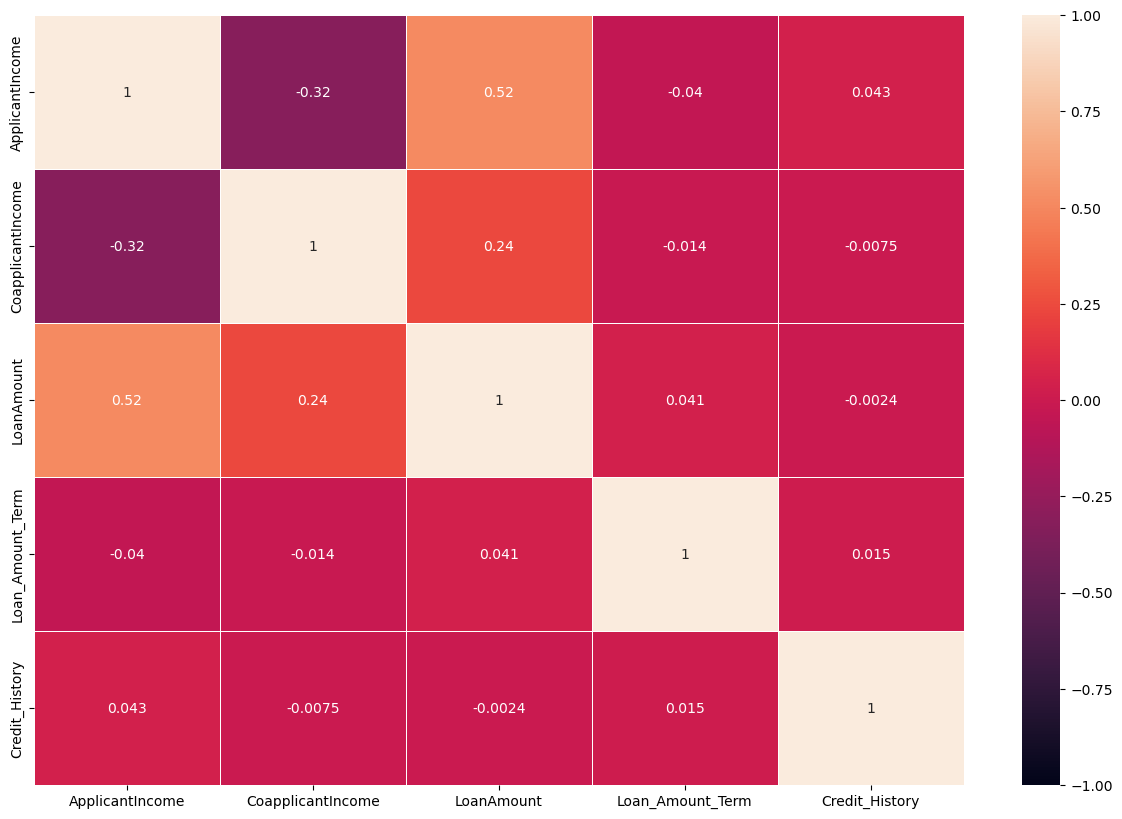

In [31]:
plt.figure(figsize=(15,10))
sns.heatmap(numeric_data.corr(method = 'spearman'), annot=True, linewidths=.5, vmin = -1, vmax = 1, fmt = '.2g')

In [32]:
data.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

### <span style="color:green">DATA PREPROCESSING

#### <span style="color:blue">Imputing Null Values

In [33]:
# Imputing null for categorical variables with mode
data['Dependents'] = data['Dependents'].fillna(data['Dependents'].mode()[0])
data['Gender'] = data['Gender'].fillna(data['Gender'].mode()[0])
data['Married'] = data['Married'].fillna(data['Married'].mode()[0])
data['Education'] = data['Education'].fillna(data['Education'].mode()[0])
data['Self_Employed'] = data['Self_Employed'].fillna(data['Self_Employed'].mode()[0])
data['Credit_History'] = data['Credit_History'].fillna(data['Credit_History'].mode()[0])

In [34]:
# Imputing null for numerical variables with median - mean was not chosen because of outliers in the data
data['LoanAmount'].fillna(data['LoanAmount'].median(), inplace = True)
data['Loan_Amount_Term'].fillna(data['Loan_Amount_Term'].median(), inplace = True)

In [35]:
data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [36]:
# Calculating VIF for all numerical variables
x = data[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']]

vif = pd.DataFrame()
vif["features"] = x.columns
vif["vif_Factor"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif

,features,vif_Factor
0,ApplicantIncome,2.845794
1,CoapplicantIncome,1.458045
2,LoanAmount,6.457683
3,Loan_Amount_Term,3.753503


In [37]:
# Calculating VIF for all numerical variables except LoanAmount


x = data[['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term']]

vif = pd.DataFrame()
vif["features"] = x.columns
vif["vif_Factor"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
vif

,features,vif_Factor
0,ApplicantIncome,1.724216
1,CoapplicantIncome,1.287776
2,Loan_Amount_Term,2.072653


<span style="color:blue">Since the VIF drops significantly after removing Loan Amount we drop loan amount from prediction

In [38]:
data.drop(columns=['LoanAmount'], inplace=True)

In [39]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,360.0,1.0,Urban,Y


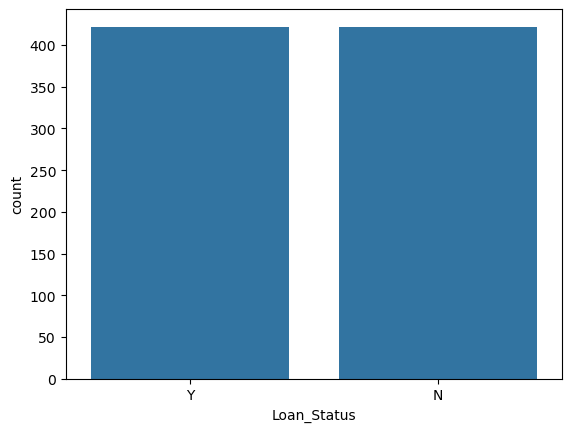

In [40]:
import imblearn
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=0)
x = data.drop(columns = ['Loan_Status'])
y = data['Loan_Status']
x, y = ros.fit_resample(x, y)
ax = sns.countplot(x=y)


In [41]:
df1=pd.concat([x,y],axis=1)
df1.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,360.0,1.0,Urban,Y


#### <span style="color:blue">OUTLIERS TREATMENT

<span style="color:blue">There are outliers in ApplicantIncome, CoapplicantIncome and Loan_Amount_Term. However, in real life, we would expect these variables to display some outliers. Therefore, it is important not to treat them

### <span style="color:green"> DATA PREP FOR MODELLING

In [43]:
cat_cols = ['Dependents','Gender','Married','Education','Self_Employed','Credit_History','Property_Area']
dummies = pd.get_dummies(df1[cat_cols])
dummies

,Credit_History,Dependents_0,Dependents_1,Dependents_2,Dependents_3+,Gender_Female,Gender_Male,Married_No,Married_Yes,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1.0,True,False,False,False,False,True,True,False,True,False,True,False,False,False,True
1,1.0,False,True,False,False,False,True,False,True,True,False,True,False,True,False,False
2,1.0,True,False,False,False,False,True,False,True,True,False,False,True,False,False,True
3,1.0,True,False,False,False,False,True,False,True,False,True,True,False,False,False,True
4,1.0,True,False,False,False,False,True,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,0.0,False,False,False,True,False,True,False,True,True,False,True,False,False,True,False
840,1.0,False,True,False,False,False,True,False,True,True,False,True,False,False,False,True
841,1.0,False,False,False,True,False,True,False,True,False,True,True,False,True,False,False
842,0.0,False,False,True,False,False,True,False,True,True,False,True,False,True,False,False


In [44]:
df1 = pd.concat([df1, dummies], axis = 1)

In [45]:
df1.shape

(844, 27)

In [46]:
df1 = df1.drop(cat_cols, axis = 1)

In [47]:
df1.shape

(844, 19)

In [48]:
y = df1['Loan_Status']
y.value_counts()

Loan_Status
Y    422
N    422
Name: count, dtype: int64

In [49]:
from sklearn.preprocessing import LabelEncoder
df1['Loan_Status']

0      Y
1      N
2      Y
3      Y
4      Y
      ..
839    N
840    N
841    N
842    N
843    N
Name: Loan_Status, Length: 844, dtype: object

In [50]:
labelencoder = LabelEncoder()
# Convert the target variable into binary format
y = labelencoder.fit_transform(df1['Loan_Status'])
y

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0,

In [51]:
# segregate the target variable
x = df1.drop(columns = ['Loan_Status'])

# splitting data into training and test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42, stratify = y)
x_train.shape

(590, 18)

In [52]:
x_test.shape

(254, 18)

In [53]:
y_train.shape

(590,)

In [54]:
y_test.shape

(254,)

### <span style="color:green"> MODEL DEVELOPMENT

In [55]:
# FOR CONFUSION MATRIX HEATMAP
def draw_cm(actual,predicted):
    cm = confusion_matrix(actual,predicted)
    sns.heatmap(cm,annot=True, fmt='.2f', xticklabels=[0,1], yticklabels=[0,1])
    plt.ylabel('observed')
    plt.xlabel('Predicted')
    plt.show()

In [56]:
def get_metrics_score(clf, flag = True):
    '''
    Function to calculate the following metrics of a fitted classifier - Accuracy, Recall and Precision
    Params:
    -------
    clf: a fitted classifier to predict values
    '''

    # defining an empty list to store train and test results
    score_list=[] 
    # predict on both the training and test sets
    pred_train = clf.predict(x_train)
    pred_test = clf.predict(x_test)
    # calculate Accuracy
    train_acc = accuracy_score(y_train, pred_train)
    test_acc = accuracy_score(y_test, pred_test)
    # calculate Recall
    train_recall = recall_score(y_train, pred_train)
    test_recall = recall_score(y_test, pred_test)
    # calculate Precision
    train_precision = precision_score(y_train, pred_train)
    test_precision = precision_score(y_test, pred_test)
    # calculate F1 score
    F1_Score = f1_score(y_test, pred_test)
    # calculate ROC_AUC_score
    Roc_Auc_score = roc_auc_score(y_test, pred_test)    
    # add these scores to score_list
    score_list.extend((train_acc, test_acc, train_recall, test_recall, train_precision, test_precision, f1_score, roc_auc_score))
        
    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True: 
        print("Accuracy on training set : ", train_acc)
        print("Accuracy on test set : ", test_acc)
        print("Recall on training set : ", train_recall)
        print("Recall on test set : ", test_recall)
        print("Precision on training set : ", train_precision)
        print("Precision on test set : ", test_precision)
        print("F1_Score : ", F1_Score)
        print("Roc_Auc_score : ", Roc_Auc_score)
    
    return score_list # returning the list with train and test scores

## <span style="color:blue"> LOGISTIC REGRESSION CLASSIFIER

In [57]:
lr = LogisticRegression(random_state = 30, class_weight = None)
lr.fit(x_train, y_train)
predictions_lr = lr.predict(x_test)

In [58]:
predictions_lr.shape

(254,)

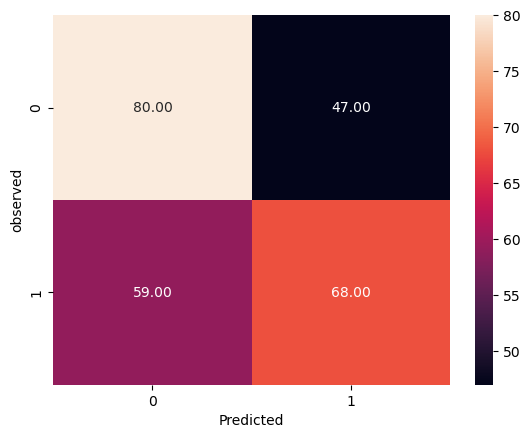

In [59]:
draw_cm(y_test, predictions_lr)

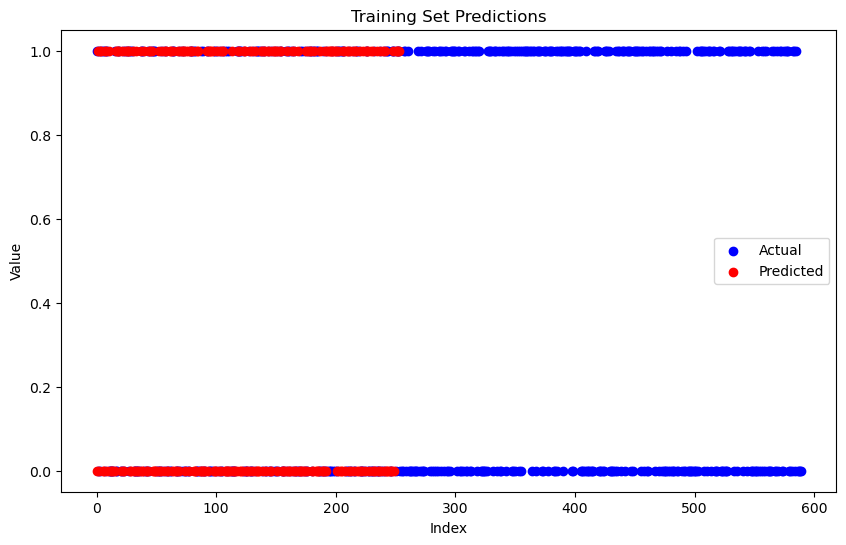

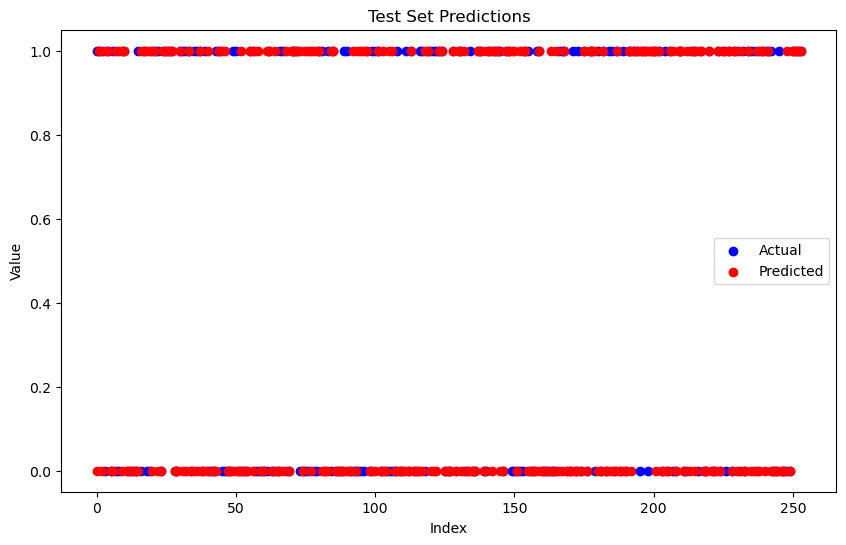

In [60]:
# Plotting the training set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_train)), y_train, color='blue', label='Actual')
plt.scatter(range(len(predictions_lr)), predictions_lr, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Training Set Predictions')
plt.legend()
plt.show()

# Plotting the test set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(predictions_lr)), predictions_lr, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Test Set Predictions')
plt.legend()
plt.show()

In [61]:
print(classification_report(y_test, predictions_lr))

              precision    recall  f1-score   support

           0       0.58      0.63      0.60       127
           1       0.59      0.54      0.56       127

    accuracy                           0.58       254
   macro avg       0.58      0.58      0.58       254
weighted avg       0.58      0.58      0.58       254



In [62]:
logistic_regression_scores = get_metrics_score(lr)

Accuracy on training set :  0.5661016949152542
Accuracy on test set :  0.5826771653543307
Recall on training set :  0.5796610169491525
Recall on test set :  0.5354330708661418
Precision on training set :  0.5643564356435643
Precision on test set :  0.591304347826087
F1_Score :  0.5619834710743802
Roc_Auc_score :  0.5826771653543307


## <span style="color:blue"> XGBOOST CLASSIFIER

In [63]:
xgb = XGBClassifier(random_state = 42, scale_pos_weight = 1)
xgb.fit(x_train, y_train)
predictions_xgb = xgb.predict(x_test)

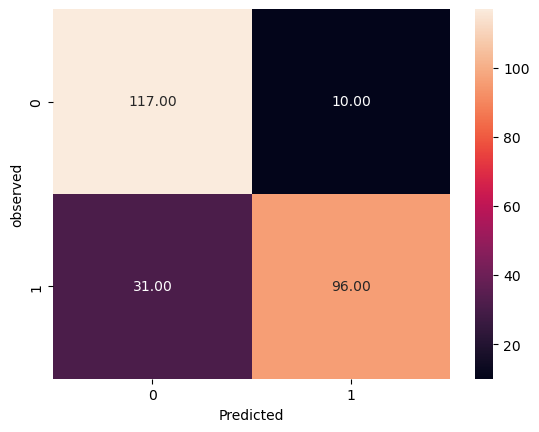

In [64]:
draw_cm(y_test,predictions_xgb)

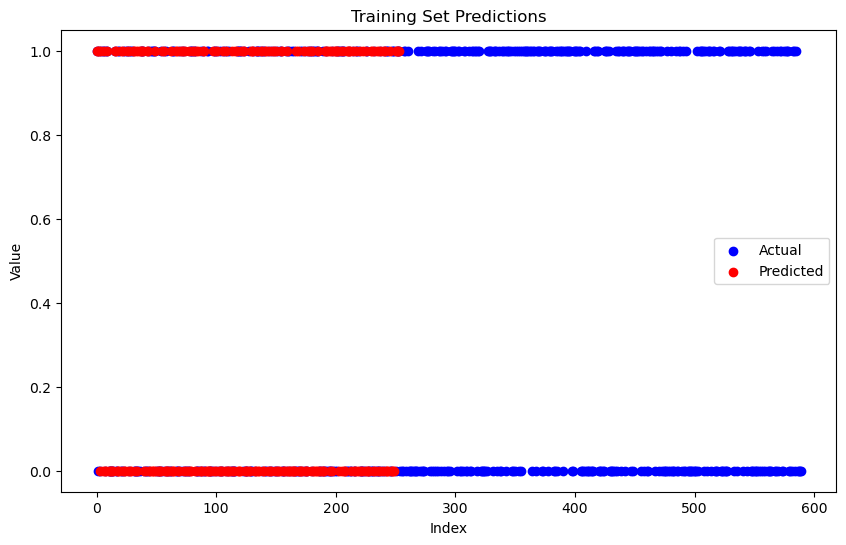

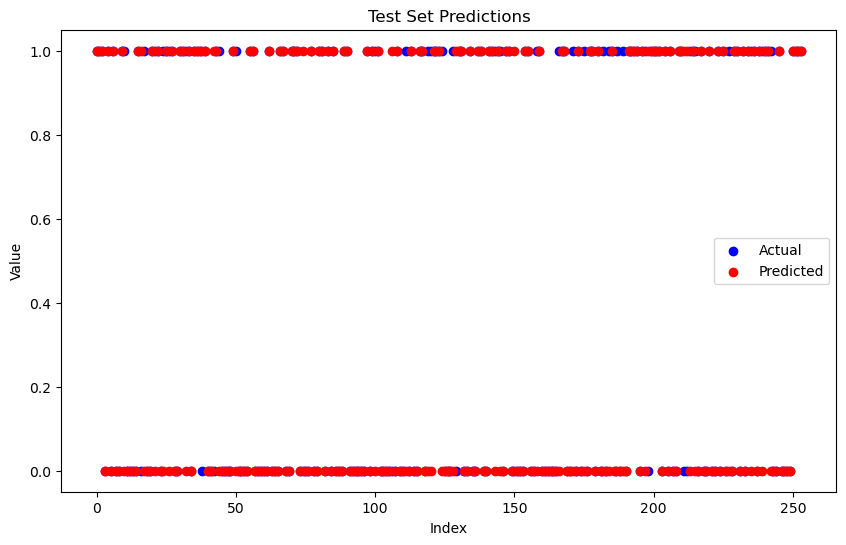

In [65]:
# Plotting the training set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_train)), y_train, color='blue', label='Actual')
plt.scatter(range(len(predictions_xgb)), predictions_xgb, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Training Set Predictions')
plt.legend()
plt.show()

# Plotting the test set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(predictions_xgb)), predictions_xgb, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Test Set Predictions')
plt.legend()
plt.show()

In [66]:
print(classification_report(y_test,predictions_xgb))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85       127
           1       0.91      0.76      0.82       127

    accuracy                           0.84       254
   macro avg       0.85      0.84      0.84       254
weighted avg       0.85      0.84      0.84       254



In [67]:
xgb_scores = get_metrics_score(xgb)

Accuracy on training set :  0.9915254237288136
Accuracy on test set :  0.8385826771653543
Recall on training set :  0.9898305084745763
Recall on test set :  0.7559055118110236
Precision on training set :  0.9931972789115646
Precision on test set :  0.9056603773584906
F1_Score :  0.8240343347639485
Roc_Auc_score :  0.8385826771653544


## <span style="color:blue">RANDOM FOREST CLASSIFIER

In [68]:
rf = RandomForestClassifier(random_state = 42, class_weight = 'balanced')
rf.fit(x_train, y_train)
predictions_rf = rf.predict(x_test)

In [69]:
predictions_rf.shape

(254,)

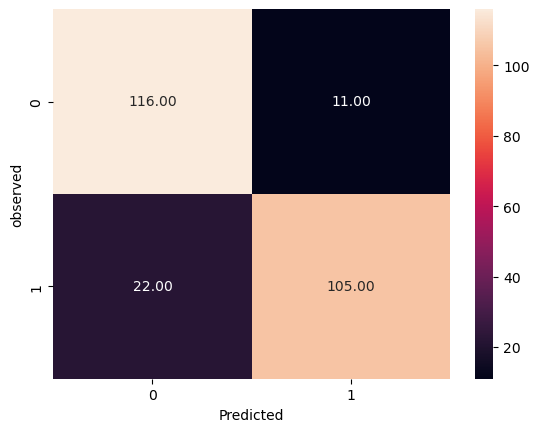

In [70]:
draw_cm(y_test,predictions_rf)

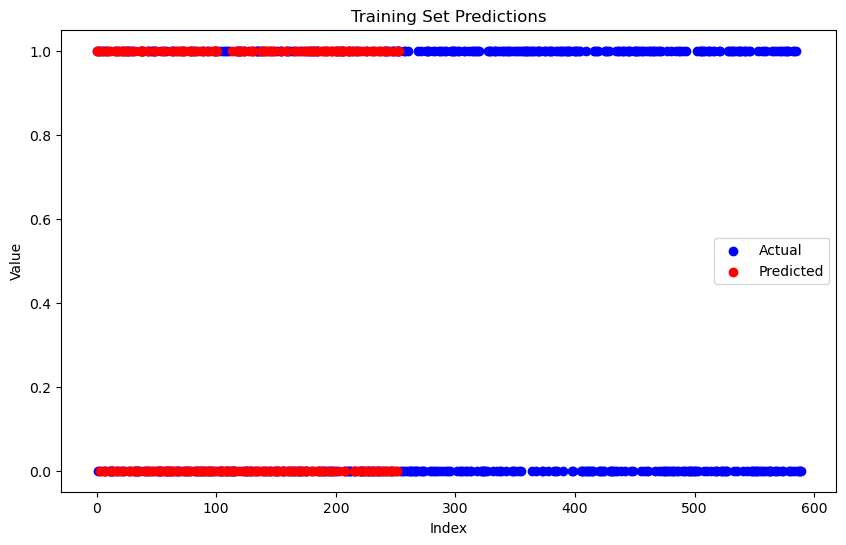

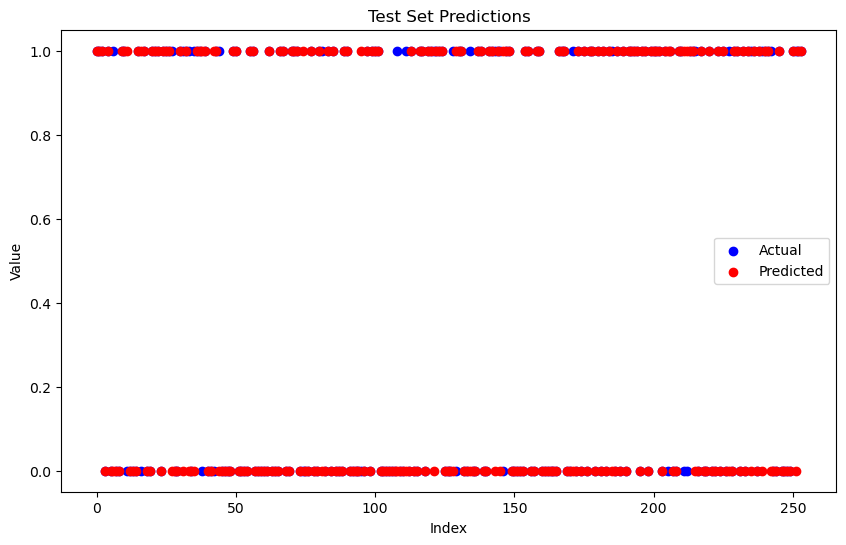

In [71]:
# Plotting the training set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_train)), y_train, color='blue', label='Actual')
plt.scatter(range(len(predictions_rf)), predictions_rf, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Training Set Predictions')
plt.legend()
plt.show()

# Plotting the test set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(predictions_rf)), predictions_rf, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Test Set Predictions')
plt.legend()
plt.show()

In [72]:
print(classification_report(y_test, predictions_rf))

              precision    recall  f1-score   support

           0       0.84      0.91      0.88       127
           1       0.91      0.83      0.86       127

    accuracy                           0.87       254
   macro avg       0.87      0.87      0.87       254
weighted avg       0.87      0.87      0.87       254



In [73]:
rf_scores = get_metrics_score(rf)

Accuracy on training set :  0.9983050847457627
Accuracy on test set :  0.8700787401574803
Recall on training set :  0.9966101694915255
Recall on test set :  0.8267716535433071
Precision on training set :  1.0
Precision on test set :  0.9051724137931034
F1_Score :  0.8641975308641975
Roc_Auc_score :  0.8700787401574803


## <span style="color:blue">BAGGING RANDOM FOREST CLASSIFIER

In [74]:
baggingrf = BaggingClassifier(rf, random_state = 42)
baggingrf.fit(x_train, y_train)
predictions_baggingrf = baggingrf.predict(x_test)

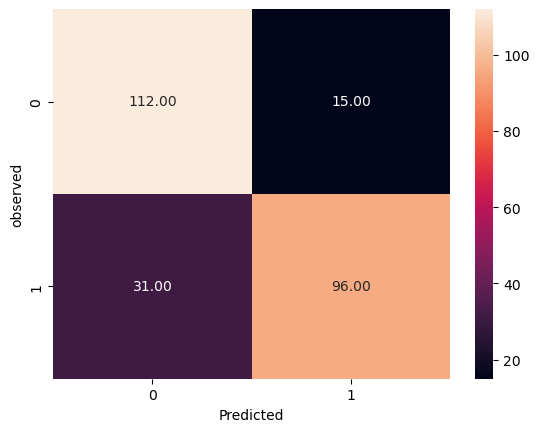

In [75]:
draw_cm(y_test,predictions_baggingrf)

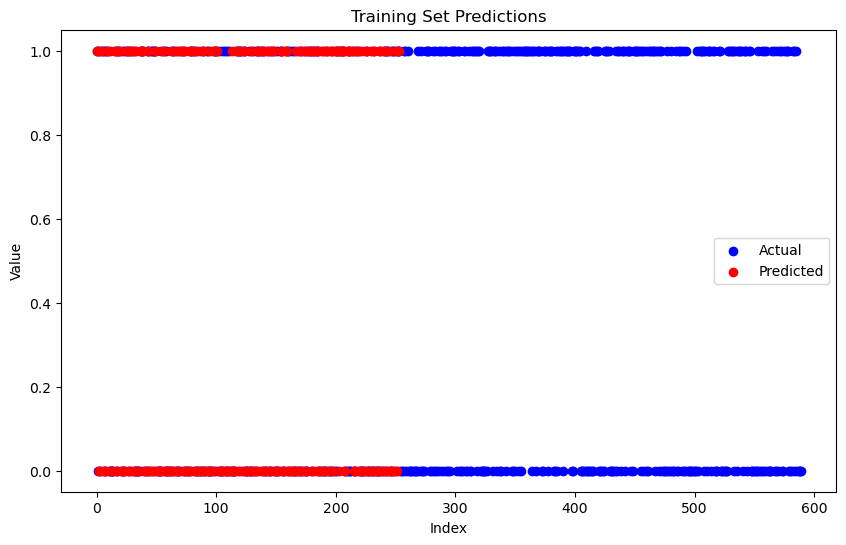

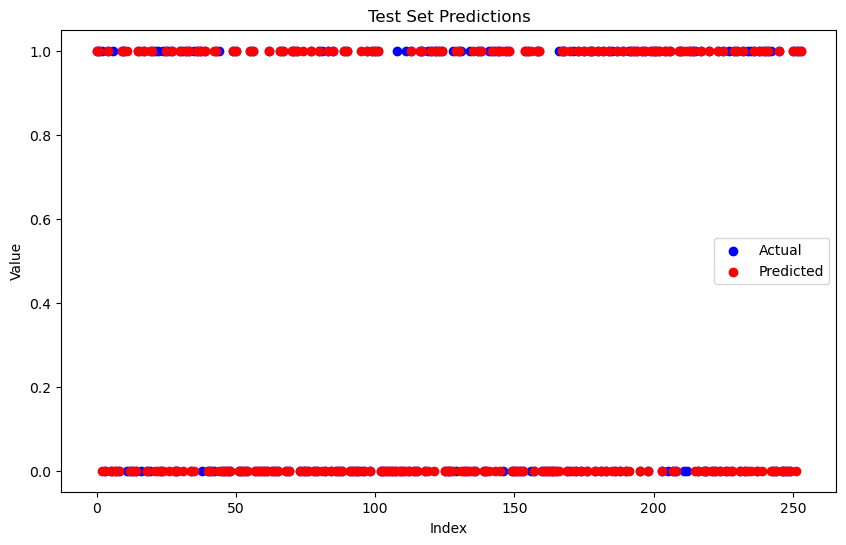

In [76]:
# Plotting the training set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_train)), y_train, color='blue', label='Actual')
plt.scatter(range(len(predictions_baggingrf)), predictions_baggingrf, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Training Set Predictions')
plt.legend()
plt.show()

# Plotting the test set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(predictions_baggingrf)), predictions_baggingrf, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Test Set Predictions')
plt.legend()
plt.show()

In [77]:
baggingrf_scores = get_metrics_score(baggingrf)

Accuracy on training set :  0.9745762711864406
Accuracy on test set :  0.8188976377952756
Recall on training set :  0.9796610169491525
Recall on test set :  0.7559055118110236
Precision on training set :  0.9697986577181208
Precision on test set :  0.8648648648648649
F1_Score :  0.8067226890756303
Roc_Auc_score :  0.8188976377952756


## <span style="color:blue">SUPPORT VECTOR MACHINE

In [79]:
from sklearn.svm import SVC
svm = SVC(kernel='linear')
svm.fit(x_train,y_train)
predictions_svm = svm.predict(x_test)

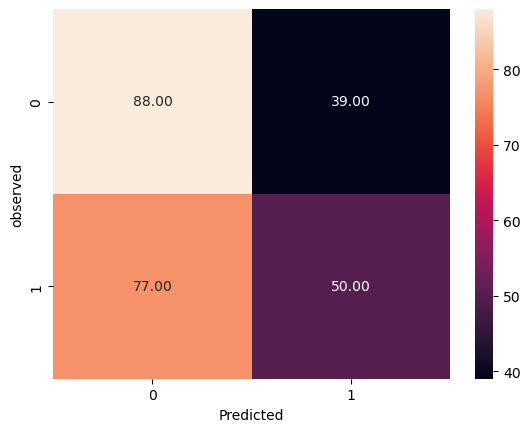

In [80]:
draw_cm(y_test,predictions_svm)

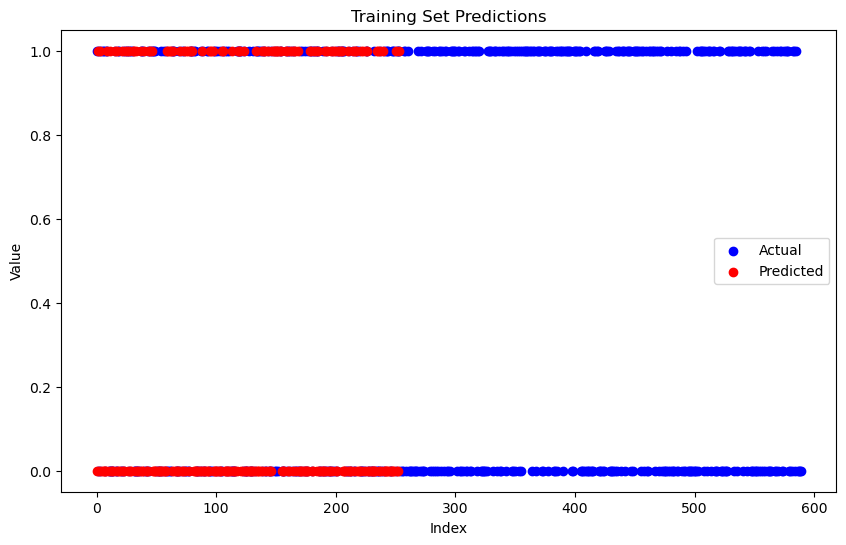

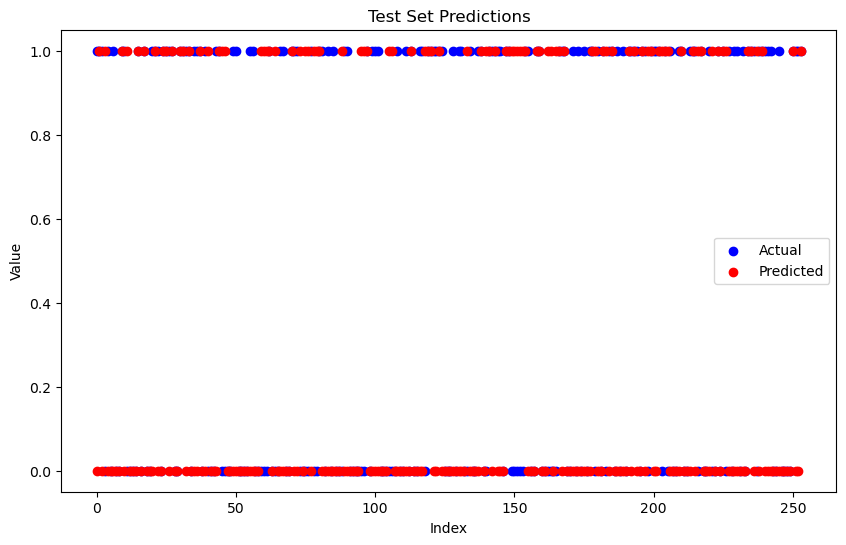

In [81]:
# Plotting the training set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_train)), y_train, color='blue', label='Actual')
plt.scatter(range(len(predictions_svm)), predictions_svm, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Training Set Predictions')
plt.legend()
plt.show()

# Plotting the test set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(predictions_svm)), predictions_svm, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Test Set Predictions')
plt.legend()
plt.show()

In [82]:
svm_scores = get_metrics_score(svm)

Accuracy on training set :  0.5457627118644067
Accuracy on test set :  0.5433070866141733
Recall on training set :  0.42033898305084744
Recall on test set :  0.3937007874015748
Precision on training set :  0.5610859728506787
Precision on test set :  0.5617977528089888
F1_Score :  0.462962962962963
Roc_Auc_score :  0.5433070866141732


## <span style="color:blue">DECISION TREE CLASSIFIER

In [83]:
from sklearn.tree import DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier()
dt_classifier.fit(x_train,y_train)
predictions_dt = dt_classifier.predict(x_test)

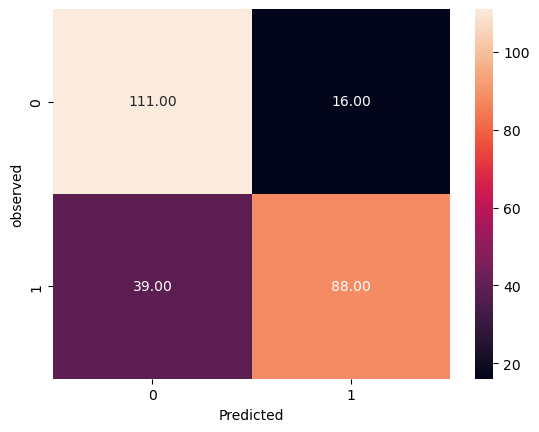

In [84]:
draw_cm(y_test,predictions_dt)

In [85]:
dt_scores = get_metrics_score(dt_classifier)

Accuracy on training set :  0.9983050847457627
Accuracy on test set :  0.7834645669291339
Recall on training set :  0.9966101694915255
Recall on test set :  0.6929133858267716
Precision on training set :  1.0
Precision on test set :  0.8461538461538461
F1_Score :  0.761904761904762
Roc_Auc_score :  0.7834645669291339


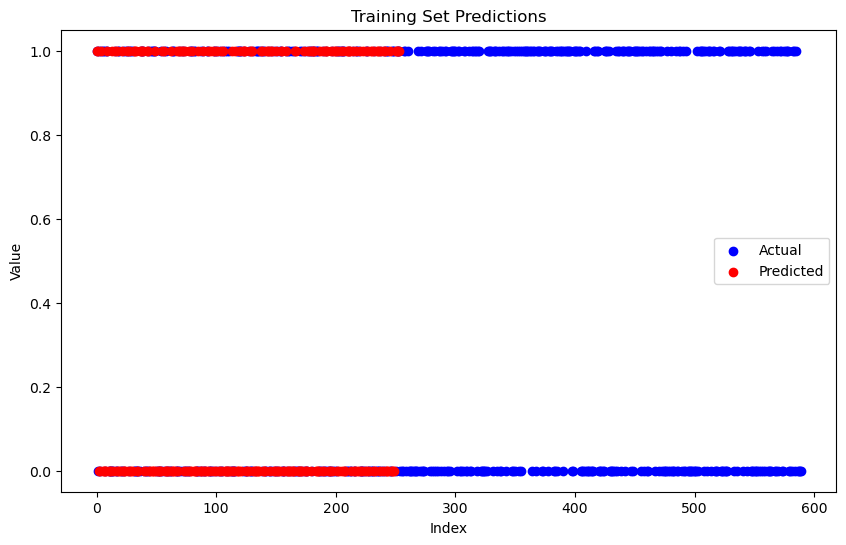

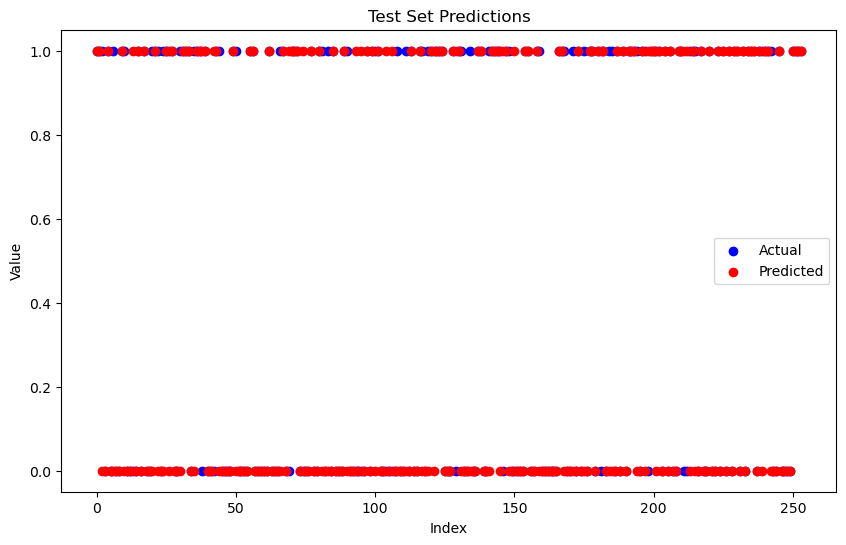

In [86]:
# Plotting the training set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_train)), y_train, color='blue', label='Actual')
plt.scatter(range(len(predictions_dt)), predictions_dt, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Training Set Predictions')
plt.legend()
plt.show()

# Plotting the test set predictions
plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(predictions_dt)), predictions_dt, color='red', label='Predicted')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Test Set Predictions')
plt.legend()
plt.show()

## <span style="color:blue">CHOOSING BEST MODEL

In [87]:
pd.DataFrame(data = {'Random Forest': rf_scores, 'Bagging Random Forest': baggingrf_scores, 
                     'Logistic Regression': logistic_regression_scores, 'SVM': svm_scores, 'XGBoost': xgb_scores,'Decision Tree':dt_scores}, 
             index = ['Accuracy - Train', 'Accuracy - Test', 'Recall - Train', 'Recall - Test',
'Precision - Train', 'Precision - Test', 'F1', 'ROC'])

,Random Forest,Bagging Random Forest,Logistic Regression,SVM,XGBoost,Decision Tree
Accuracy - Train,0.998305,0.974576,0.566102,0.545763,0.991525,0.998305
Accuracy - Test,0.870079,0.818898,0.582677,0.543307,0.838583,0.783465
Recall - Train,0.99661,0.979661,0.579661,0.420339,0.989831,0.99661
Recall - Test,0.826772,0.755906,0.535433,0.393701,0.755906,0.692913
Precision - Train,1.0,0.969799,0.564356,0.561086,0.993197,1.0
Precision - Test,0.905172,0.864865,0.591304,0.561798,0.90566,0.846154
F1,<function f1_score at 0x00000169BEE66700>,<function f1_score at 0x00000169BEE66700>,<function f1_score at 0x00000169BEE66700>,<function f1_score at 0x00000169BEE66700>,<function f1_score at 0x00000169BEE66700>,<function f1_score at 0x00000169BEE66700>
ROC,<function roc_auc_score at 0x00000169BEE7CB80>,<function roc_auc_score at 0x00000169BEE7CB80>,<function roc_auc_score at 0x00000169BEE7CB80>,<function roc_auc_score at 0x00000169BEE7CB80>,<function roc_auc_score at 0x00000169BEE7CB80>,<function roc_auc_score at 0x00000169BEE7CB80>


On the basis of the 6 models Random forest and XGBoost are found to perform best

In [88]:
from sklearn.model_selection import KFold, cross_val_score

clf = RandomForestClassifier(random_state=42)

k_folds = KFold(n_splits = 5)

scores = cross_val_score(clf, x, y, cv = k_folds)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))

Cross Validation Scores:  [0.72781065 0.68047337 0.72189349 0.79881657 0.98809524]
Average CV Score:  0.783417864187095
Number of CV Scores used in Average:  5


In [89]:
from sklearn.model_selection import KFold, cross_val_score

clf = XGBClassifier(random_state=42)

k_folds = KFold(n_splits = 5)

scores = cross_val_score(clf, x, y, cv = k_folds)

print("Cross Validation Scores: ", scores)
print("Average CV Score: ", scores.mean())
print("Number of CV Scores used in Average: ", len(scores))


Cross Validation Scores:  [0.76331361 0.73372781 0.75739645 0.84023669 0.98214286]
Average CV Score:  0.8153634826711749
Number of CV Scores used in Average:  5


<span style="color:blue">On the basis of CV criteria XGBoost is found to perform well but the differnce in CV is insignificant so we do rely on the primary criteria of Accuracy. So, RANDOM FOREST is found to be the best model.

# <span style="color:GREEN">ROC CURVE PLOT FOR RANDOM FOREST

In [90]:
def plot_roc_curve(y_test, y_pred):
    """
    plots the roc curve based of the probabilities
    """

    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    plt.plot(fpr, tpr,color='green')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

model 1 AUC score: 0.8700787401574803


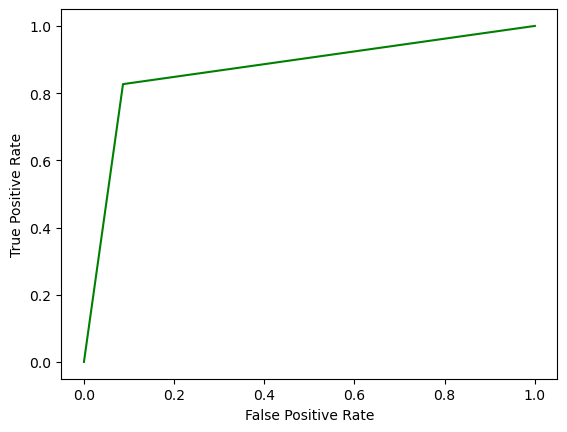

In [91]:
plot_roc_curve(y_test, predictions_rf)
print(f'model 1 AUC score: {roc_auc_score(y_test, predictions_rf)}')

## <span style="color:GREEN">ROC CURVE PLOT FOR XGBOOST

model 1 AUC score: 0.8385826771653544


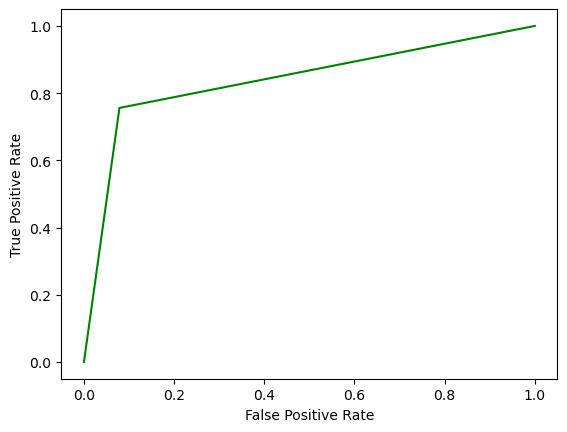

In [92]:
plot_roc_curve(y_test, predictions_xgb)
print(f'model 1 AUC score: {roc_auc_score(y_test, predictions_xgb)}')

### <span style="color:GREEN">FEATURE IMPORTANCE

### <span style="color:blue">RANDOM FOREST

In [93]:
importances=rf.feature_importances_

In [94]:
# Sort the feature importance in descending order
#
sorted_indices = np.argsort(importances)[::-1]
 
feat_labels = df1.columns
 
for f in range(x_train.shape[1]):
    print("%2d) %-*s %f" % (f + 1, 30,
                            feat_labels[sorted_indices[f]],
                            importances[sorted_indices[f]]))

 1) ApplicantIncome                0.402385
 2) CoapplicantIncome              0.217221
 3) Loan_Amount_Term               0.064755
 4) Loan_Status                    0.029275
 5) Property_Area_Rural            0.027706
 6) Self_Employed_Yes              0.027495
 7) Dependents_0                   0.024175
 8) Property_Area_Semiurban        0.023202
 9) Married_Yes                    0.021874
10) Education_Graduate             0.020240
11) Dependents_1                   0.019068
12) Dependents_2                   0.018673
13) Married_No                     0.018437
14) Education_Not Graduate         0.018413
15) Self_Employed_No               0.018065
16) Gender_Male                    0.016792
17) Dependents_3+                  0.016736
18) Gender_Female                  0.015485


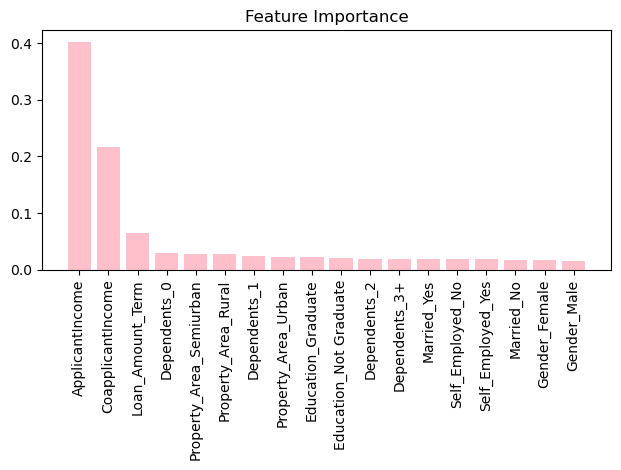

In [95]:
plt.title('Feature Importance')
plt.bar(range(x_train.shape[1]), importances[sorted_indices], align='center',color = 'pink')
plt.xticks(range(x_train.shape[1]), x_train.columns[sorted_indices], rotation=90)
plt.tight_layout()
plt.show()

######                                                                                                                                                                                                             -- Shrabani Das